# Tract-wise white-matter associations for the six orthogonal exposome subfactors

## Model used here
For each subfactor, WM features are the outcomes and the selected subfactor is the target predictor:

`WM feature ~ target subfactor + age + sex + image quality`

The notebook:
1. runs the six subfactor models in discovery and replication
2. reruns the General Exposome model as a reference
3. summarizes split-half reproducibility, FDR significance, and similarity to the General Exposome WM profile;
4. generates one split-half heatmap per subfactor;
5. generates a compact 2×3 supplementary figure with all six subfactors on a common color scale;

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.patches import Polygon, Rectangle
from matplotlib.cm import ScalarMappable
from pathlib import Path
from IPython.display import display

import partial_r as pr
import importlib
importlib.reload(pr)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


<module 'partial_r' from '/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/code/partial_r.py'>

## 1. Paths and data

In [2]:
ROOT_DIR = Path('/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome')
RESULTS_DIR = ROOT_DIR / 'output_data' / 'results'
OUT_DIR = RESULTS_DIR / 'reviewer_revision' / 'subfactor_tractwise'
FIG_DIR = RESULTS_DIR / 'supplemental_figures' / 'subfactor_tractwise'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Use the same harmonized NODDI + macrostructure datasets as Figure 2.
dfA = pd.read_csv(RESULTS_DIR / 'dfA_macro_plus_NODDI_12_10.csv')
dfB = pd.read_csv(RESULTS_DIR / 'dfB_macro_plus_NODDI_12_10.csv')

# Matched discovery / replication splits.
dfA = dfA[dfA['matched_group'] == 1].copy()
dfB = dfB[dfB['matched_group'] == 2].copy()

print('Discovery:', dfA.shape)
print('Replication:', dfB.shape)

Discovery: (4078, 1508)
Replication: (4096, 1508)


## 2. Apply the same bundle-column cleanup as Figure 2

In [3]:
def clean_bundle_columns(df):
    df = df.copy()

    # Drop tract-profile mean summaries only; keep macro metric mean_length_mm.
    bundle_cols_mean = [c for c in df.columns if c.startswith('bundle_') and c.endswith('_mean')]
    df = df.drop(columns=bundle_cols_mean, errors='ignore')

    # Retain median tract summaries, stripping only the terminal _median suffix.
    df = df.rename(columns=lambda c: c[:-len('_median')]
        if c.startswith('bundle_') and c.endswith('_median')
        else c)

    return df


dfA = clean_bundle_columns(dfA)
dfB = clean_bundle_columns(dfB)

msmt_cols = [c for c in dfA.columns if c.startswith('bundle_')]
print('Number of NODDI + macro WM features:', len(msmt_cols))
if len(msmt_cols) != 1302:
    print('WARNING: expected 1,302 features; inspect columns before continuing.')
if not any(c.endswith('_mean_length_mm') for c in msmt_cols):
    raise RuntimeError('mean_length_mm is missing after cleanup.')

Number of NODDI + macro WM features: 1302


## 3. Metric labels / ordering for Figure 2-style heatmaps

In [4]:
PREFIXES = ['Association_', 'Cerebellum_', 'Commissure_', 'ProjectionBrainstem_', 'ProjectionBasalGanglia_']
STOPWORDS = {'of', 'and', 'in', 'for', 'to', 'with', 'on', 'at'}
RE_MM_SUFFIX = re.compile(r'\s*mm[23]?\s*$', flags=re.IGNORECASE)


def clean_metrics_name(name: str) -> str:
    name = str(name).replace('_', ' ')
    name = RE_MM_SUFFIX.sub('', name).strip()

    upper = name.upper()
    if upper.startswith('NODDI'):
        return ' '.join(w.upper() for w in name.split())

    ordinal_allowed = 'quarter' in name.lower()

    def ordinalize(token: str) -> str:
        n = int(token)
        if n % 10 == 1 and n % 100 != 11: return f'{n}st'
        if n % 10 == 2 and n % 100 != 12: return f'{n}nd'
        if n % 10 == 3 and n % 100 != 13: return f'{n}rd'
        return f'{n}th'

    cleaned = []
    for w in name.split():
        if w.isdigit():
            cleaned.append(ordinalize(w) if ordinal_allowed else w)
        elif w.lower() in STOPWORDS:
            cleaned.append(w.lower())
        else:
            cleaned.append(w.capitalize())
    return ' '.join(cleaned)


def extract_metric_name(col):
    if not col.startswith('bundle_'):
        return None
    parts = col[len('bundle_'):].split('_')
    if len(parts) < 3:
        return None
    return '_'.join(parts[2:])


noddi_macro_metrics = sorted({
    m for c in dfA.columns
    if (m := extract_metric_name(c)) is not None
})
noddi_macro_metrics_dict = {m: clean_metrics_name(m) for m in noddi_macro_metrics}

print('Metric count:', len(noddi_macro_metrics))
print(noddi_macro_metrics)


Metric count: 21
['1st_quarter_volume_mm3', '2nd_and_3rd_quarter_volume_mm3', '4th_quarter_volume_mm3', 'NODDI_icvf', 'NODDI_isovf', 'NODDI_od', 'area_of_end_region_1_mm2', 'area_of_end_region_2_mm2', 'curl', 'elongation', 'irregularity', 'mean_length_mm', 'radius_of_end_region_1_mm', 'radius_of_end_region_2_mm', 'span_mm', 'total_area_of_end_regions_mm2', 'total_radius_of_end_regions_mm', 'total_surface_area_mm2', 'total_volume_mm3', 'volume_of_end_branches_1', 'volume_of_end_branches_2']


## 4. Define General Exposome reference and six subfactors

In [5]:
SUBFACTORS = [
    'School',
    'Family_Values',
    'Family_Turmoil',
    'Dense_Urban_Poverty',
    'Extracurriculars',
    'Screen_Time',
]

DISPLAY_NAMES = {
    'General_SES': 'General Exposome',
    'School': 'School',
    'Family_Values': 'Family Values',
    'Family_Turmoil': 'Family Turmoil',
    'Dense_Urban_Poverty': 'Dense Urban Poverty',
    'Extracurriculars': 'Extracurriculars',
    'Screen_Time': 'Screen Time',
}

required = ['age', 'sex', 't1post_dwi_contrast', 'General_SES'] + SUBFACTORS
for split_name, df in [('Discovery', dfA), ('Replication', dfB)]:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f'{split_name} is missing required variables: {missing}')

# Helpful empirical check before modeling.
factor_vars = ['General_SES'] + SUBFACTORS
print('Discovery factor correlations:')
display(dfA[factor_vars].corr().round(3))
print('Replication factor correlations:')
display(dfB[factor_vars].corr().round(3))

Discovery factor correlations:


,General_SES,School,Family_Values,Family_Turmoil,Dense_Urban_Poverty,Extracurriculars,Screen_Time
General_SES,1.000,0.007,-0.099,-0.019,-0.119,0.112,-0.045
School,0.007,1.000,0.008,-0.053,0.015,-0.002,-0.052
Family_Values,-0.099,0.008,1.000,-0.020,-0.049,0.053,-0.017
Family_Turmoil,-0.019,-0.053,-0.020,1.000,-0.067,0.124,0.009
Dense_Urban_Poverty,-0.119,0.015,-0.049,-0.067,1.000,0.025,-0.028
Extracurriculars,0.112,-0.002,0.053,0.124,0.025,1.000,0.146
Screen_Time,-0.045,-0.052,-0.017,0.009,-0.028,0.146,1.000


Replication factor correlations:


,General_SES,School,Family_Values,Family_Turmoil,Dense_Urban_Poverty,Extracurriculars,Screen_Time
General_SES,1.000,0.012,-0.058,-0.044,-0.106,0.118,-0.084
School,0.012,1.000,0.038,-0.069,0.036,-0.001,-0.031
Family_Values,-0.058,0.038,1.000,-0.043,-0.078,0.057,-0.042
Family_Turmoil,-0.044,-0.069,-0.043,1.000,-0.045,0.118,0.027
Dense_Urban_Poverty,-0.106,0.036,-0.078,-0.045,1.000,0.058,-0.027
Extracurriculars,0.118,-0.001,0.057,0.118,0.058,1.000,0.114
Screen_Time,-0.084,-0.031,-0.042,0.027,-0.027,0.114,1.000


## 5. Run the General Exposome reference model

In [6]:
GENERAL_COVARIATES = ['age', 'sex', 't1post_dwi_contrast', 'General_SES']

print('Running General Exposome reference models...')
general_A = pr.run_partial_r(dfA, msmt_cols, GENERAL_COVARIATES, include_etiv=False, target_cov='General_SES')
general_B = pr.run_partial_r(dfB, msmt_cols, GENERAL_COVARIATES, include_etiv=False, target_cov='General_SES')

general_A.to_csv(OUT_DIR / 'General_SES_discovery.csv', index=False)
general_B.to_csv(OUT_DIR / 'General_SES_replication.csv', index=False)
print('Saved General Exposome reference effects.')

Running General Exposome reference models...
Saved General Exposome reference effects.


## 6. Run each subfactor individually

In [7]:
subfactor_results = {}

for factor in SUBFACTORS:
    covariates = ['age', 'sex', 't1post_dwi_contrast', factor]

    print(f'\nRunning {factor}: Discovery')
    res_A = pr.run_partial_r(dfA, msmt_cols, covariates, include_etiv=False, target_cov=factor)

    print(f'Running {factor}: Replication')
    res_B = pr.run_partial_r(dfB, msmt_cols, covariates, include_etiv=False, target_cov=factor)

    subfactor_results[(factor, 'A')] = res_A
    subfactor_results[(factor, 'B')] = res_B

    res_A.to_csv(OUT_DIR / f'{factor}_discovery.csv', index=False)
    res_B.to_csv(OUT_DIR / f'{factor}_replication.csv', index=False)

print('\n[DONE] All six subfactor models completed and saved.')


Running School: Discovery
Running School: Replication

Running Family_Values: Discovery
Running Family_Values: Replication

Running Family_Turmoil: Discovery
Running Family_Turmoil: Replication

Running Dense_Urban_Poverty: Discovery
Running Dense_Urban_Poverty: Replication

Running Extracurriculars: Discovery
Running Extracurriculars: Replication

Running Screen_Time: Discovery
Running Screen_Time: Replication

[DONE] All six subfactor models completed and saved.


## 7. Summarize reproducibility, significance, and similarity to the General Exposome WM profile

In [8]:
def merge_effects(a, b, label_a='A', label_b='B'):
    return a[['feature', 'partial_r', 'p_fdr']].merge(
        b[['feature', 'partial_r', 'p_fdr']],
        on='feature',
        suffixes=(f'_{label_a}', f'_{label_b}'),
        validate='one_to_one')

summary_rows = []
profile_rows = []

for factor in SUBFACTORS:
    A = subfactor_results[(factor, 'A')]
    B = subfactor_results[(factor, 'B')]

    AB = merge_effects(A, B, 'A', 'B')
    split_r = AB[['partial_r_A', 'partial_r_B']].corr().iloc[0, 1]

    # Similarity to primary General Exposome effect profile within each split.
    AG = merge_effects(A, general_A, 'subfactor', 'general')
    BG = merge_effects(B, general_B, 'subfactor', 'general')
    general_r_A = AG[['partial_r_subfactor', 'partial_r_general']].corr().iloc[0, 1]
    general_r_B = BG[['partial_r_subfactor', 'partial_r_general']].corr().iloc[0, 1]

    sig_A = A['p_fdr'] < 0.05
    sig_B = B['p_fdr'] < 0.05
    both = AB[(AB['p_fdr_A'] < 0.05) & (AB['p_fdr_B'] < 0.05)]

    summary_rows.append({
        'factor': factor,
        'factor_display': DISPLAY_NAMES[factor],
        'split_concordance_r': split_r,
        'mean_abs_partial_r_discovery': A['partial_r'].abs().mean(),
        'mean_abs_partial_r_replication': B['partial_r'].abs().mean(),
        'n_FDR_sig_discovery': int(sig_A.sum()),
        'n_FDR_sig_replication': int(sig_B.sum()),
        'n_FDR_sig_both_splits': int(len(both)),
        'profile_corr_with_General_discovery': general_r_A,
        'profile_corr_with_General_replication': general_r_B})

    profile_rows.extend([
        {'factor': factor, 'split': 'Discovery', 'r_with_General': general_r_A},
        {'factor': factor, 'split': 'Replication', 'r_with_General': general_r_B}])

summary_df = pd.DataFrame(summary_rows)
profile_df = pd.DataFrame(profile_rows)

summary_df.to_csv(OUT_DIR / 'subfactor_summary.csv', index=False)
profile_df.to_csv(OUT_DIR / 'subfactor_vs_General_profile_correlations.csv', index=False)

display(summary_df.round(3))

,factor,factor_display,split_concordance_r,mean_abs_partial_r_discovery,mean_abs_partial_r_replication,n_FDR_sig_discovery,n_FDR_sig_replication,n_FDR_sig_both_splits,profile_corr_with_General_discovery,profile_corr_with_General_replication
0,School,School,0.125,0.013,0.016,1,0,0,-0.010,-0.427
1,Family_Values,Family Values,0.517,0.020,0.017,107,12,3,-0.695,-0.586
2,Family_Turmoil,Family Turmoil,0.239,0.017,0.014,2,0,0,-0.459,-0.148
3,Dense_Urban_Poverty,Dense Urban Poverty,0.400,0.026,0.022,295,181,44,-0.564,-0.460
4,Extracurriculars,Extracurriculars,0.129,0.019,0.018,0,0,0,0.283,-0.002
5,Screen_Time,Screen Time,0.427,0.022,0.015,116,2,0,-0.694,-0.390


## 8. Plotting helper for a compact split-half heatmap

The existing Figure 2 helper adds a separate colorbar and dataset legend to every axis, which is ideal for a single heatmap but too crowded for a six-panel figure. The compact helper below keeps the same logic:

- collapse left/right homologous tracts;
- discovery = upper-left triangle;
- replication = lower-right triangle;
- gray cells unless **both** splits survive FDR q < .05;
- one common color scale across all six factors.


In [9]:
MACRO_ORDER = [
    '1st_quarter_volume_mm3', '2nd_and_3rd_quarter_volume_mm3', '4th_quarter_volume_mm3',
    'volume_of_end_branches_1', 'volume_of_end_branches_2', 'total_volume_mm3',
    'area_of_end_region_1_mm2', 'area_of_end_region_2_mm2', 'total_area_of_end_regions_mm2',
    'total_surface_area_mm2', 'radius_of_end_region_1_mm', 'radius_of_end_region_2_mm',
    'total_radius_of_end_regions_mm', 'irregularity', 'curl', 'elongation',
    'mean_length_mm', 'span_mm'
]

BUNDLE_PALETTE = {
    'Association_': '#4E79A7',
    'ProjectionBrainstem_': '#F28E2B',
    'ProjectionBasalGanglia_': '#59A14F',
    'Cerebellum_': '#E15759',
    'Commissure_': '#B07AA1',
}


def bundle_type(bundle):
    for prefix in PREFIXES:
        if str(bundle).startswith(prefix):
            return prefix
    return None

def clean_bundle_name(bundle):
    name = re.sub(r'(L|R)$', '', str(bundle))
    for prefix in PREFIXES:
        if name.startswith(prefix):
            name = name[len(prefix):]
            break
    return re.sub(r'(?<!^)(?=[A-Z])', ' ', name).strip()

def prepare_split_half(A, B, factor):
    A = pr.collapse_lr(A[A['covariate'] == factor]).copy()
    B = pr.collapse_lr(B[B['covariate'] == factor]).copy()

    A = A.groupby(['bundle', 'metric', 'covariate'], as_index=False).agg({'partial_r': 'mean', 'p_fdr': 'mean'})
    B = B.groupby(['bundle', 'metric', 'covariate'], as_index=False).agg({'partial_r': 'mean', 'p_fdr': 'mean'})

    unique_metrics = A['metric'].unique().tolist()
    micro = sorted([m for m in unique_metrics if m.startswith('NODDI')])
    other = [m for m in unique_metrics if not m.startswith('NODDI')]
    macro = [m for m in MACRO_ORDER if m in other]
    metric_order = micro + macro

    matA = A.pivot(index='bundle', columns='metric', values='partial_r').reindex(columns=metric_order)
    pA = A.pivot(index='bundle', columns='metric', values='p_fdr').reindex_like(matA)
    matB = B.pivot(index='bundle', columns='metric', values='partial_r').reindex(index=matA.index, columns=metric_order)
    pB = B.pivot(index='bundle', columns='metric', values='p_fdr').reindex_like(matA)

    return matA, pA, matB, pB, micro

def compact_split_half_heatmap(A, B, factor, ax, cmap, norm, show_ylabels=True, show_xlabels=True):
    matA, pA, matB, pB, micro = prepare_split_half(A, B, factor)
    bundles = matA.index.tolist()
    metrics = matA.columns.tolist()

    ax.set_xlim(0, len(metrics))
    ax.set_ylim(0, len(bundles))
    ax.invert_yaxis()

    for i, bundle in enumerate(bundles):
        for j, metric in enumerate(metrics):
            valA = matA.loc[bundle, metric]
            valB = matB.loc[bundle, metric]
            sigA = pd.notna(pA.loc[bundle, metric]) and pA.loc[bundle, metric] < 0.05
            sigB = pd.notna(pB.loc[bundle, metric]) and pB.loc[bundle, metric] < 0.05

            # Match the main Figure 2 display rule: gray unless significant in both splits.
            if not (sigA and sigB):
                ax.add_patch(Rectangle((j, i), 1, 1, facecolor='gainsboro', edgecolor='none'))
                continue

            ax.add_patch(Polygon([(j, i + 1), (j, i), (j + 1, i)], facecolor=cmap(norm(valA)), edgecolor='none'))
            ax.add_patch(Polygon([(j + 1, i + 1), (j + 1, i), (j, i + 1)], facecolor=cmap(norm(valB)), edgecolor='none'))

    ax.set_xticks(np.arange(len(metrics)) + 0.5)
    ax.set_yticks(np.arange(len(bundles)) + 0.5)

    if show_xlabels:
        ax.set_xticklabels([noddi_macro_metrics_dict.get(m, m) for m in metrics], rotation=55, ha='right', fontsize=6)
    else:
        ax.set_xticklabels([])

    if show_ylabels:
        ax.set_yticklabels([clean_bundle_name(b) for b in bundles], fontsize=5.5)
        for tick, raw_bundle in zip(ax.get_yticklabels(), bundles):
            bt = bundle_type(raw_bundle)
            if bt in BUNDLE_PALETTE:
                tick.set_color(BUNDLE_PALETTE[bt])
                tick.set_fontweight('bold')
    else:
        ax.set_yticklabels([])

    if len(micro) > 0:
        ax.axvline(len(micro), color='black', lw=1.0)

    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    return ax

## 9. Shared color scale across all subfactor panels

In [10]:
all_vals = []
for factor in SUBFACTORS:
    all_vals.append(subfactor_results[(factor, 'A')]['partial_r'].to_numpy())
    all_vals.append(subfactor_results[(factor, 'B')]['partial_r'].to_numpy())
all_vals = np.concatenate(all_vals)

vmax = np.nanpercentile(np.abs(all_vals), 98)
norm = Normalize(vmin=-vmax, vmax=vmax)
cmap = sns.diverging_palette(250, 15, s=95, l=55, as_cmap=True)
print('Shared display range:', (-vmax, vmax))

Shared display range: (np.float64(-0.05435726278663633), np.float64(0.05435726278663633))


## 10. Save one Figure 2-style heatmap per subfactor

In [11]:
for factor in SUBFACTORS:
    A = subfactor_results[(factor, 'A')]
    B = subfactor_results[(factor, 'B')]

    fig, ax = plt.subplots(figsize=(9, 7))
    compact_split_half_heatmap(A, B, factor, ax, cmap, norm, show_ylabels=True, show_xlabels=True)
    ax.set_title(f"{DISPLAY_NAMES[factor]}\nUpper-left = Discovery; lower-right = Replication", fontsize=12, fontweight='bold')

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label('Partial r (target subfactor)')

    fig.tight_layout()
    svg = FIG_DIR / f'{factor}_split_half_heatmap.svg'
    png = FIG_DIR / f'{factor}_split_half_heatmap.png'
    fig.savefig(svg, bbox_inches='tight')
    fig.savefig(png, dpi=300, bbox_inches='tight')
    plt.close(fig)

print('Saved six individual subfactor heatmaps to:', FIG_DIR)

Saved six individual subfactor heatmaps to: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/subfactor_tractwise


## 11. Compact 2×3 supplementary figure

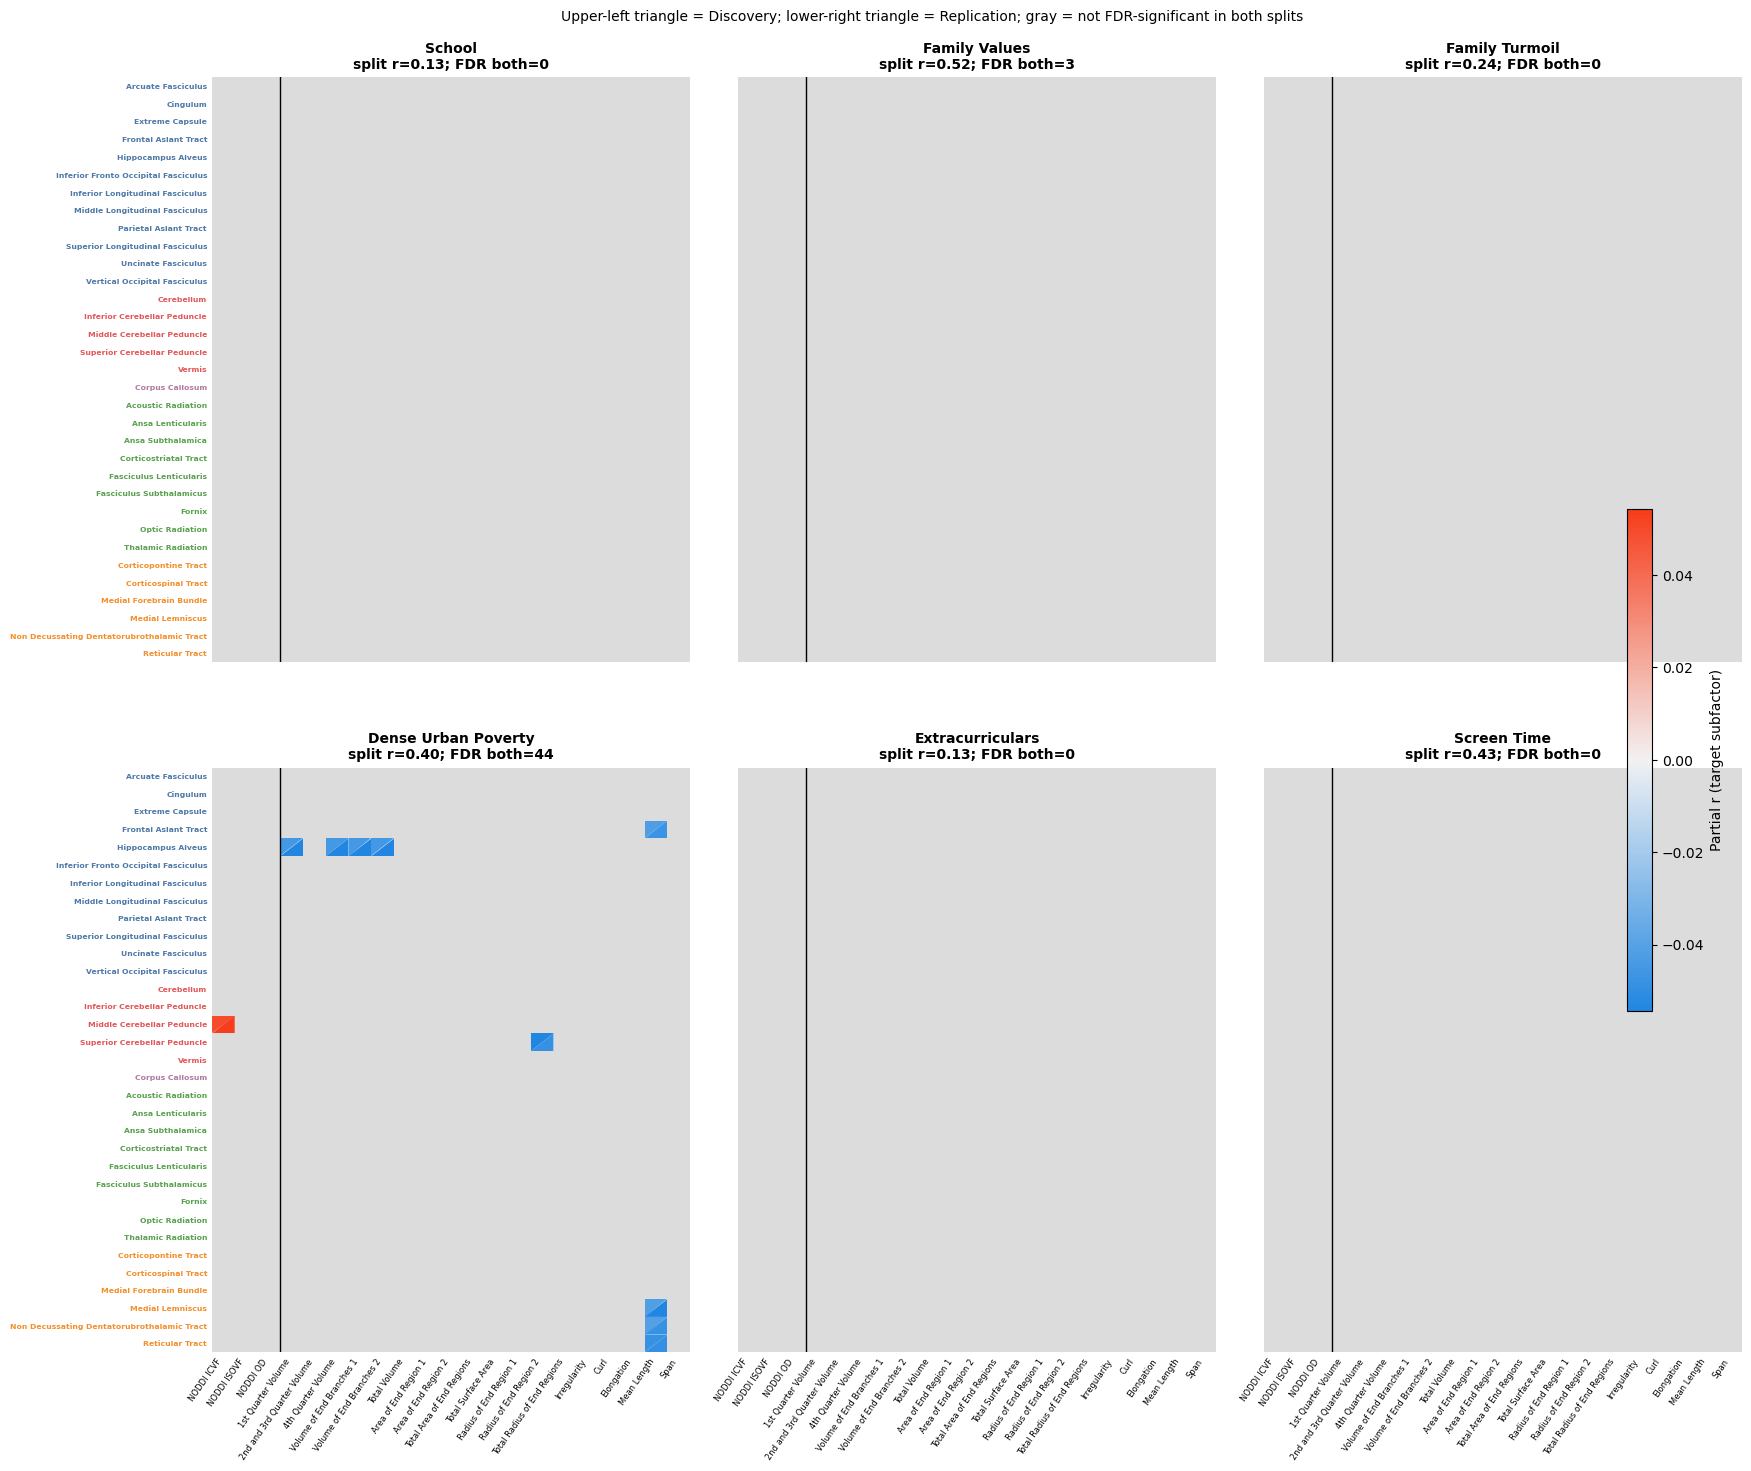

Saved: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/subfactor_tractwise/SUPP_subfactor_tractwise_2x3.svg
Saved: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/subfactor_tractwise/SUPP_subfactor_tractwise_2x3.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, factor in enumerate(SUBFACTORS):
    ax = axes[idx]
    compact_split_half_heatmap(
        subfactor_results[(factor, 'A')],
        subfactor_results[(factor, 'B')],
        factor,
        ax,
        cmap,
        norm,
        show_ylabels=(idx % 3 == 0),
        show_xlabels=(idx >= 3),
    )

    row = summary_df.loc[summary_df['factor'] == factor].iloc[0]
    ax.set_title(
        f"{DISPLAY_NAMES[factor]}\n"
        f"split r={row['split_concordance_r']:.2f}; "
        f"FDR both={int(row['n_FDR_sig_both_splits'])}",
        fontsize=10,
        fontweight='bold'
    )

# Shared colorbar.
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.018, pad=0.012)
cbar.set_label('Partial r (target subfactor)', fontsize=10)

# Figure-level split-half key.
fig.text(0.5, 0.995, 'Upper-left triangle = Discovery; lower-right triangle = Replication; gray = not FDR-significant in both splits',
         ha='center', va='top', fontsize=10)

fig.subplots_adjust(left=0.10, right=0.95, bottom=0.10, top=0.95, wspace=0.10, hspace=0.18)

svg = FIG_DIR / 'SUPP_subfactor_tractwise_2x3.svg'
png = FIG_DIR / 'SUPP_subfactor_tractwise_2x3.png'
fig.savefig(svg, bbox_inches='tight')
fig.savefig(png, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', svg)
print('Saved:', png)

## 12. Optional concise summary: similarity among WM effect profiles

,General_SES,School,Family_Values,Family_Turmoil,Dense_Urban_Poverty,Extracurriculars,Screen_Time
General_SES,1.00,-0.01,-0.70,-0.46,-0.56,0.28,-0.69
School,-0.01,1.00,0.08,-0.24,-0.06,0.02,-0.03
Family_Values,-0.70,0.08,1.00,0.23,0.35,-0.30,0.37
Family_Turmoil,-0.46,-0.24,0.23,1.00,0.22,-0.05,0.35
Dense_Urban_Poverty,-0.56,-0.06,0.35,0.22,1.00,-0.01,0.57
Extracurriculars,0.28,0.02,-0.30,-0.05,-0.01,1.00,-0.01
Screen_Time,-0.69,-0.03,0.37,0.35,0.57,-0.01,1.00


,General_SES,School,Family_Values,Family_Turmoil,Dense_Urban_Poverty,Extracurriculars,Screen_Time
General_SES,1.00,-0.43,-0.59,-0.15,-0.46,-0.00,-0.39
School,-0.43,1.00,0.27,-0.13,0.30,0.19,0.17
Family_Values,-0.59,0.27,1.00,-0.08,0.32,-0.07,0.12
Family_Turmoil,-0.15,-0.13,-0.08,1.00,-0.04,0.14,0.05
Dense_Urban_Poverty,-0.46,0.30,0.32,-0.04,1.00,0.31,0.36
Extracurriculars,-0.00,0.19,-0.07,0.14,0.31,1.00,0.31
Screen_Time,-0.39,0.17,0.12,0.05,0.36,0.31,1.00


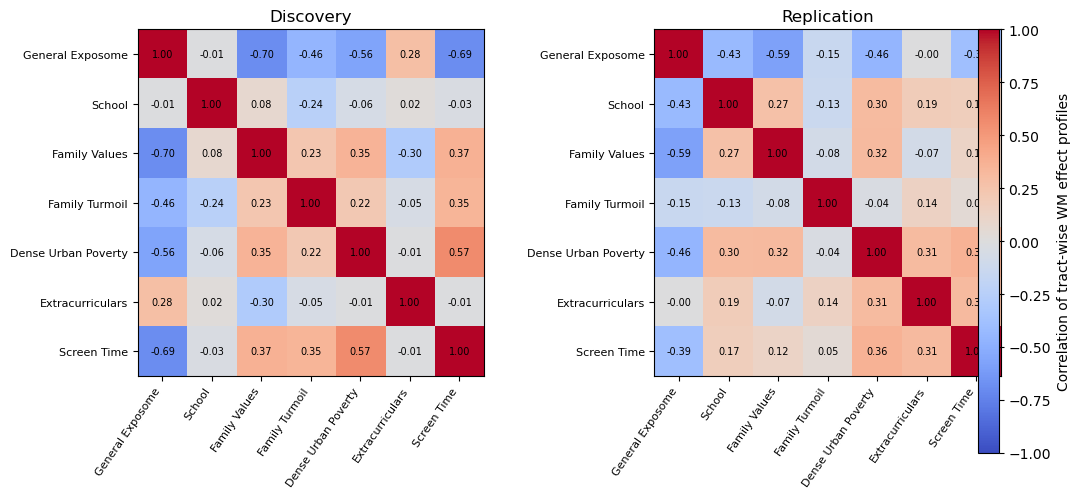

In [13]:
def effect_vector(result_df):
    return result_df.set_index('feature')['partial_r'].sort_index()

profile_order = ['General_SES'] + SUBFACTORS

vectors_A = {'General_SES': effect_vector(general_A)}
vectors_B = {'General_SES': effect_vector(general_B)}
for factor in SUBFACTORS:
    vectors_A[factor] = effect_vector(subfactor_results[(factor, 'A')])
    vectors_B[factor] = effect_vector(subfactor_results[(factor, 'B')])

profile_matrix_A = pd.DataFrame(vectors_A)[profile_order].corr()
profile_matrix_B = pd.DataFrame(vectors_B)[profile_order].corr()

profile_matrix_A.to_csv(OUT_DIR / 'WM_effect_profile_correlations_discovery.csv')
profile_matrix_B.to_csv(OUT_DIR / 'WM_effect_profile_correlations_replication.csv')

display(profile_matrix_A.round(2))
display(profile_matrix_B.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
labels = [DISPLAY_NAMES[x] for x in profile_order]

for ax, mat, title in [
    (axes[0], profile_matrix_A, 'Discovery'),
    (axes[1], profile_matrix_B, 'Replication'),
]:
    im = ax.imshow(mat.values, vmin=-1, vmax=1, cmap='coolwarm')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=55, ha='right', fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(title)

    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f'{mat.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)

fig.colorbar(im, ax=axes.tolist(), fraction=0.025, pad=0.03, label='Correlation of tract-wise WM effect profiles')
fig.subplots_adjust(wspace=0.25, bottom=0.25)

svg = FIG_DIR / 'SUPP_subfactor_effect_profile_correlations.svg'
png = FIG_DIR / 'SUPP_subfactor_effect_profile_correlations.png'
fig.savefig(svg, bbox_inches='tight')
fig.savefig(png, dpi=300, bbox_inches='tight')
plt.show()


In [19]:
# ------------------------------------------------------------------
# Exact feature-level FDR replication
# Keep L/R separate -- do NOT use collapse_lr()
# ------------------------------------------------------------------
def parse_feature(feature):
    name=str(feature)

    if name.startswith("bundle_"):
        name=name[len("bundle_"):]

    parts=name.split("_")

    # Existing notebook convention:
    # first two components = bundle
    # remaining components = metric
    if len(parts)<3:
        raise ValueError(f"Could not parse feature: {feature}")

    bundle="_".join(parts[:2])
    metric="_".join(parts[2:])
    return bundle,metric

def clean_bundle_name_with_side(bundle):
    name=str(bundle)
    side=""

    if name.endswith("L"):
        name=name[:-1]
        side=" (L)"
    elif name.endswith("R"):
        name=name[:-1]
        side=" (R)"

    for prefix in PREFIXES:
        if name.startswith(prefix):
            name=name[len(prefix):]
            break

    name=re.sub(r"(?<!^)(?=[A-Z])"," ",name).strip()
    return name+side

def replicated_features(factor):
    A=subfactor_results[(factor,"A")].copy()
    B=subfactor_results[(factor,"B")].copy()

    # Be explicit in case run_partial_r contains rows for multiple covariates
    if "covariate" in A.columns:
        A=A[A["covariate"]==factor].copy()
    if "covariate" in B.columns:
        B=B[B["covariate"]==factor].copy()

    A=A[["feature","partial_r","p_fdr"]]
    B=B[["feature","partial_r","p_fdr"]]

    AB=A.merge(
        B,
        on="feature",
        suffixes=("_A","_B"),
        validate="one_to_one"
    )

    # Exact same feature must survive FDR in both independent splits
    AB=AB[
        (AB["p_fdr_A"]<.05)&
        (AB["p_fdr_B"]<.05)
    ].copy()

    parsed=AB["feature"].apply(parse_feature)
    AB["bundle"]=[x[0] for x in parsed]
    AB["metric"]=[x[1] for x in parsed]

    AB["tract_label"]=AB["bundle"].map(clean_bundle_name_with_side)
    AB["metric_label"]=AB["metric"].map(
        lambda x:noddi_macro_metrics_dict.get(x,clean_metrics_name(x))
    )

    AB["label"]=AB["tract_label"]+" — "+AB["metric_label"]
    AB["mean_effect"]=(AB["partial_r_A"]+AB["partial_r_B"])/2

    # NODDI first, then macrostructure in existing manuscript order
    metric_order=[
        *sorted([m for m in AB["metric"].unique() if str(m).startswith("NODDI")]),
        *[m for m in MACRO_ORDER if m in AB["metric"].unique()]
    ]
    metric_rank={m:i for i,m in enumerate(metric_order)}

    AB["_metric_order"]=AB["metric"].map(metric_rank).fillna(999)
    AB=AB.sort_values(
        ["_metric_order","metric_label","tract_label"]
    ).reset_index(drop=True)

    return AB

fv=replicated_features("Family_Values")
dup=replicated_features("Dense_Urban_Poverty")

print(f"Family Values replicated FDR features: {len(fv)}")
print(f"Dense Urban Poverty replicated FDR features: {len(dup)}")

display(fv[[
    "feature","tract_label","metric_label",
    "partial_r_A","partial_r_B","p_fdr_A","p_fdr_B"
]].round(4))

display(dup[[
    "feature","tract_label","metric_label",
    "partial_r_A","partial_r_B","p_fdr_A","p_fdr_B"
]].round(4))

Family Values replicated FDR features: 3
Dense Urban Poverty replicated FDR features: 44


,feature,tract_label,metric_label,partial_r_A,partial_r_B,p_fdr_A,p_fdr_B
0,bundle_Association_InferiorLongitudinalFascicu...,Inferior Longitudinal Fasciculus (R),Mean Length,-0.0592,-0.0553,0.0094,0.0433
1,bundle_Association_SuperiorLongitudinalFascicu...,Superior Longitudinal Fasciculus (L),Mean Length,-0.0576,-0.0698,0.0101,0.0101
2,bundle_Association_InferiorLongitudinalFascicu...,Inferior Longitudinal Fasciculus (R),Span,-0.0585,-0.0554,0.0094,0.0433


,feature,tract_label,metric_label,partial_r_A,partial_r_B,p_fdr_A,p_fdr_B
0,bundle_Cerebellum_MiddleCerebellarPeduncle_NOD...,Middle Cerebellar Peduncle,NODDI ICVF,0.0489,0.0533,0.0131,0.0114
1,bundle_Association_ArcuateFasciculusR_NODDI_isovf,Arcuate Fasciculus (R),NODDI ISOVF,0.0749,0.0491,0.0001,0.0224
2,bundle_Association_FrontalAslantTractR_NODDI_i...,Frontal Aslant Tract (R),NODDI ISOVF,0.0597,0.0446,0.0019,0.0398
3,bundle_Association_MiddleLongitudinalFasciculu...,Middle Longitudinal Fasciculus (R),NODDI ISOVF,0.1033,0.0425,0.0000,0.0489
4,bundle_Association_SuperiorLongitudinalFascicu...,Superior Longitudinal Fasciculus (R),NODDI ISOVF,0.0751,0.0439,0.0001,0.0434
5,bundle_ProjectionBasalGanglia_AcousticRadiatio...,Acoustic Radiation (L),NODDI OD,0.0447,0.0506,0.0254,0.0179
6,bundle_Association_MiddleLongitudinalFasciculu...,Middle Longitudinal Fasciculus (R),NODDI OD,0.0435,0.0596,0.0305,0.0043
7,bundle_Association_ArcuateFasciculusL_1st_quar...,Arcuate Fasciculus (L),1st Quarter Volume,-0.0413,-0.0450,0.0411,0.0375
8,bundle_Association_HippocampusAlveusR_1st_quar...,Hippocampus Alveus (R),1st Quarter Volume,-0.0502,-0.0609,0.0107,0.0039
9,bundle_Association_SuperiorLongitudinalFascicu...,Superior Longitudinal Fasciculus (R),1st Quarter Volume,-0.0490,-0.0495,0.0130,0.0217


Discovery-Replication WM profile correlations:


,Factor,r
0,General Exposome,0.944
1,School,0.125
2,Family Values,0.517
3,Family Turmoil,0.239
4,Dense Urban Poverty,0.400
5,Extracurriculars,0.129
6,Screen Time,0.427


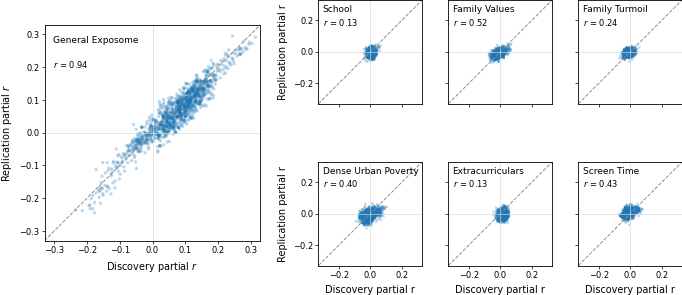

Saved:
/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/subfactor_tractwise/SUPP_subfactor_split_half_scatter.svg
/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/subfactor_tractwise/SUPP_subfactor_split_half_scatter.pdf
/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/subfactor_tractwise/SUPP_subfactor_split_half_scatter.png


In [23]:
# ================================================================
# Supplement: split-half reproducibility of WM effect profiles
# Large General Exposome panel + six subfactor panels
# ================================================================
import importlib.util
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Load figure_formatting
try:
    import figure_formatting as ff
except ImportError:
    candidates=[
        Path.cwd()/"figure_formatting.py",
        Path.cwd()/"figure_formatting(6).py",
        ROOT_DIR/"code"/"figure_formatting.py",
        ROOT_DIR/"code"/"figure_formatting(6).py",
        Path("/mnt/data/figure_formatting(6).py")
    ]
    fmt_path=next((p for p in candidates if p.exists()),None)
    if fmt_path is None:
        raise FileNotFoundError("Could not find figure_formatting.py")
    spec=importlib.util.spec_from_file_location("figure_formatting",fmt_path)
    ff=importlib.util.module_from_spec(spec)
    spec.loader.exec_module(ff)

factor_order=[
    "General_SES",
    "School",
    "Family_Values",
    "Family_Turmoil",
    "Dense_Urban_Poverty",
    "Extracurriculars",
    "Screen_Time"
]

def get_result(factor,split):
    if factor=="General_SES":
        df=general_A.copy() if split=="A" else general_B.copy()
    else:
        df=subfactor_results[(factor,split)].copy()

    if "covariate" in df.columns:
        df=df[df["covariate"]==factor].copy()

    return df[["feature","partial_r","p_fdr"]].copy()

def split_profile(factor):
    A=get_result(factor,"A")
    B=get_result(factor,"B")

    AB=A[["feature","partial_r"]].merge(
        B[["feature","partial_r"]],
        on="feature",
        suffixes=("_A","_B"),
        validate="one_to_one"
    ).dropna()

    r=pearsonr(AB["partial_r_A"],AB["partial_r_B"])[0]
    return AB,r

profiles={}
all_vals=[]

for factor in factor_order:
    AB,r=split_profile(factor)
    profiles[factor]=(AB,r)
    all_vals.extend(AB["partial_r_A"].to_numpy())
    all_vals.extend(AB["partial_r_B"].to_numpy())

all_vals=np.asarray(all_vals)
all_vals=all_vals[np.isfinite(all_vals)]
lim=np.max(np.abs(all_vals))*1.05

print("Discovery-Replication WM profile correlations:")
display(pd.DataFrame({
    "Factor":[DISPLAY_NAMES[f] for f in factor_order],
    "r":[profiles[f][1] for f in factor_order]
}).round(3))

# ------------------------------------------------
# Figure geometry
# ------------------------------------------------
fig,placeholder=ff.setup_figure(
    width_mm=180,
    height_mm=92,
    base_pt=6,
    label_pt=7,
    title_pt=7,
    sans_list=["Arial","DejaVu Sans"],
    axes_linewidth=.6,
    line_width=.7,
    margins_mm=(12,6,12,6)
)

box=placeholder.get_position()
fig.delaxes(placeholder)

outer=fig.add_gridspec(
    1,2,
    left=box.x0,
    right=box.x1,
    bottom=box.y0,
    top=box.y1,
    width_ratios=[1.08,1.82],
    wspace=.20
)

ax_general=fig.add_subplot(outer[0,0])

right=outer[0,1].subgridspec(
    2,3,
    wspace=.25,
    hspace=.25
)

domain_axes=[
    fig.add_subplot(right[i,j])
    for i in range(2)
    for j in range(3)
]

def draw_profile(ax,factor,point_size=4):
    AB,r=profiles[factor]

    ax.scatter(
        AB["partial_r_A"],
        AB["partial_r_B"],
        s=point_size,
        alpha=.28,
        edgecolors="none",
        rasterized=True
    )

    ax.plot(
        [-lim,lim],
        [-lim,lim],
        linestyle="--",
        linewidth=.7,
        color=".55"
    )

    ax.axhline(0,linewidth=.45,color=".85")
    ax.axvline(0,linewidth=.45,color=".85")

    ax.set_xlim(-lim,lim)
    ax.set_ylim(-lim,lim)
    ax.set_aspect("equal",adjustable="box")

    # Plain internal labels rather than plot titles
    ax.text(
        .04,.95,
        DISPLAY_NAMES[factor],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=6.5
    )

    ax.text(
        .04,.84,
        rf"$r$ = {r:.2f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=6
    )

    ax.tick_params(length=2,width=.5,pad=1.5)

# General Exposome
draw_profile(
    ax_general,
    "General_SES",
    point_size=6
)

ax_general.set_xlabel(r"Discovery partial $r$")
ax_general.set_ylabel(r"Replication partial $r$")

for ax in domain_axes[3:]:
    ax.set_xlabel(r"Discovery partial $r$")

domain_axes[0].set_ylabel(r"Replication partial $r$")
domain_axes[3].set_ylabel(r"Replication partial $r$")

# Six subfactors
for ax,factor in zip(domain_axes,factor_order[1:]):
    draw_profile(ax,factor,point_size=3.5)

# Reduce repeated labels
for ax in domain_axes[:3]:
    ax.tick_params(labelbottom=False)

for i,ax in enumerate(domain_axes):
    if i%3!=0:
        ax.tick_params(labelleft=False)

for ax in domain_axes[3:]:
    ax.set_xlabel("Discovery partial r")

domain_axes[0].set_ylabel("Replication partial r")
domain_axes[3].set_ylabel("Replication partial r")

# ------------------------------------------------
# Save WITHOUT autofit -- prevents axes from collapsing
# ------------------------------------------------
svg=FIG_DIR/"SUPP_subfactor_split_half_scatter.svg"
pdf=FIG_DIR/"SUPP_subfactor_split_half_scatter.pdf"
png=FIG_DIR/"SUPP_subfactor_split_half_scatter.png"

ff.save_figure(fig,str(svg),autofit=False)
ff.save_figure(fig,str(pdf),autofit=False)
fig.savefig(png,dpi=300)

plt.show()

print("Saved:")
print(svg)
print(pdf)
print(png)

Family Values replicated features: 3
Dense Urban Poverty replicated features: 44


,feature,partial_r_A,partial_r_B,p_fdr_A,p_fdr_B
0,bundle_Association_InferiorLongitudinalFascicu...,-0.0592,-0.0553,0.0094,0.0433
1,bundle_Association_SuperiorLongitudinalFascicu...,-0.0576,-0.0698,0.0101,0.0101
2,bundle_Association_InferiorLongitudinalFascicu...,-0.0585,-0.0554,0.0094,0.0433


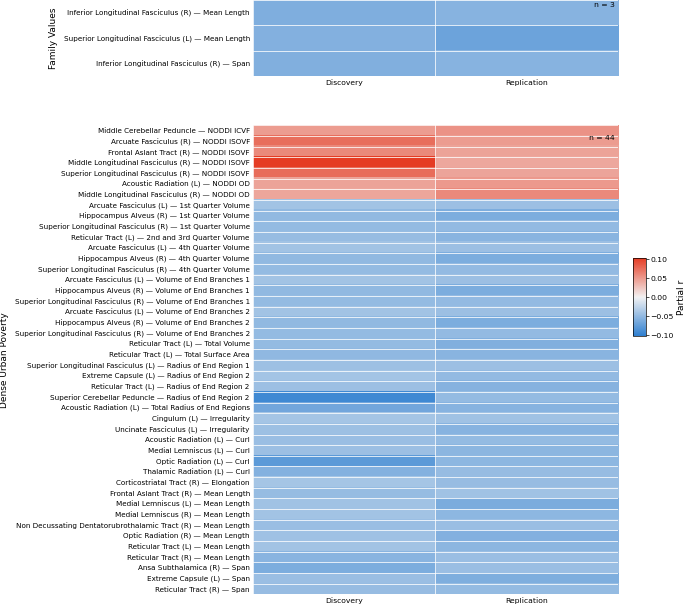

Saved:
/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/subfactor_tractwise/SUPP_exact_replicated_subfactor_features.svg
/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/subfactor_tractwise/SUPP_exact_replicated_subfactor_features.pdf
/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/supplemental_figures/subfactor_tractwise/SUPP_exact_replicated_subfactor_features.png


In [22]:
# ================================================================
# Supplement: exact FDR-replicated WM features
# Family Values = 3; Dense Urban Poverty = 44
# NO L/R COLLAPSE
# ================================================================
import re
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def parse_feature(feature):
    name=str(feature)

    if name.startswith("bundle_"):
        name=name[len("bundle_"):]

    parts=name.split("_")

    if len(parts)<3:
        raise ValueError(f"Could not parse feature: {feature}")

    bundle="_".join(parts[:2])
    metric="_".join(parts[2:])

    return bundle,metric

def clean_bundle_with_side(bundle):
    name=str(bundle)
    side=""

    if name.endswith("L"):
        name=name[:-1]
        side=" (L)"
    elif name.endswith("R"):
        name=name[:-1]
        side=" (R)"

    for prefix in PREFIXES:
        if name.startswith(prefix):
            name=name[len(prefix):]
            break

    name=re.sub(r"(?<!^)(?=[A-Z])"," ",name).strip()
    return name+side

def metric_label(metric):
    return noddi_macro_metrics_dict.get(
        metric,
        clean_metrics_name(metric)
    )

def exact_replicated(factor):
    A=get_result(factor,"A")
    B=get_result(factor,"B")

    AB=A.merge(
        B,
        on="feature",
        suffixes=("_A","_B"),
        validate="one_to_one"
    )

    AB=AB[
        (AB["p_fdr_A"]<.05)&
        (AB["p_fdr_B"]<.05)
    ].copy()

    parsed=AB["feature"].apply(parse_feature)
    AB["bundle"]=[x[0] for x in parsed]
    AB["metric"]=[x[1] for x in parsed]

    AB["tract"]=AB["bundle"].map(clean_bundle_with_side)
    AB["metric_display"]=AB["metric"].map(metric_label)
    AB["label"]=AB["tract"]+" — "+AB["metric_display"]

    metric_order=[
        *sorted([
            m for m in AB["metric"].unique()
            if str(m).startswith("NODDI")
        ]),
        *[
            m for m in MACRO_ORDER
            if m in AB["metric"].unique()
        ]
    ]

    metric_rank={m:i for i,m in enumerate(metric_order)}
    AB["_metric_rank"]=AB["metric"].map(metric_rank).fillna(999)

    AB=AB.sort_values(
        ["_metric_rank","tract"]
    ).reset_index(drop=True)

    return AB

fv=exact_replicated("Family_Values")
dup=exact_replicated("Dense_Urban_Poverty")

print("Family Values replicated features:",len(fv))
print("Dense Urban Poverty replicated features:",len(dup))

if len(fv)!=3:
    print(f"WARNING: expected 3 Family Values features, found {len(fv)}")

if len(dup)!=44:
    print(f"WARNING: expected 44 Dense Urban Poverty features, found {len(dup)}")

display(fv[[
    "feature",
    "partial_r_A",
    "partial_r_B",
    "p_fdr_A",
    "p_fdr_B"
]].round(4))

# ------------------------------------------------
# Common effect scale
# ------------------------------------------------
vals=np.concatenate([
    fv[["partial_r_A","partial_r_B"]].to_numpy().ravel(),
    dup[["partial_r_A","partial_r_B"]].to_numpy().ravel()
])

vals=vals[np.isfinite(vals)]
vmax=np.max(np.abs(vals))

norm=Normalize(vmin=-vmax,vmax=vmax)

cmap=sns.diverging_palette(
    250,15,
    s=90,
    l=52,
    center="light",
    as_cmap=True
)

# ------------------------------------------------
# Figure
# Large left margin is intentional for exact feature labels
# ------------------------------------------------
fig,placeholder=ff.setup_figure(
    width_mm=180,
    height_mm=170,
    base_pt=5.5,
    label_pt=6.5,
    title_pt=6.5,
    sans_list=["Arial","DejaVu Sans"],
    axes_linewidth=.6,
    line_width=.7,
    margins_mm=(73,7,13,6)
)

box=placeholder.get_position()
fig.delaxes(placeholder)

outer=fig.add_gridspec(
    2,2,
    left=box.x0,
    right=box.x1,
    bottom=box.y0,
    top=box.y1,
    width_ratios=[1,.035],
    height_ratios=[.14,.86],
    wspace=.08,
    hspace=.18
)

ax_fv=fig.add_subplot(outer[0,0])
ax_dup=fig.add_subplot(outer[1,0])

cbar_grid=outer[:,1].subgridspec(
    3,1,
    height_ratios=[1,.35,1]
)
cax=fig.add_subplot(cbar_grid[1,0])

def draw_exact_heatmap(ax,df,factor_label):
    matrix=df[
        ["partial_r_A","partial_r_B"]
    ].to_numpy()

    ax.imshow(
        matrix,
        cmap=cmap,
        norm=norm,
        interpolation="none",
        aspect="auto"
    )

    ax.set_xticks([0,1])
    ax.set_xticklabels([
        "Discovery",
        "Replication"
    ])

    ax.set_yticks(np.arange(len(df)))
    ax.set_yticklabels(
        df["label"],
        fontsize=5.2
    )

    ax.set_ylabel(factor_label)
    ax.tick_params(length=0,pad=2)

    # Fine white grid so every feature row is distinct
    ax.set_xticks(
        np.arange(-.5,2,1),
        minor=True
    )
    ax.set_yticks(
        np.arange(-.5,len(df),1),
        minor=True
    )

    ax.grid(
        which="minor",
        color="white",
        linewidth=.55
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

    ax.text(
        .99,.98,
        f"n = {len(df)}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=5.5
    )

    for spine in ax.spines.values():
        spine.set_visible(False)

draw_exact_heatmap(
    ax_fv,
    fv,
    "Family Values"
)

draw_exact_heatmap(
    ax_dup,
    dup,
    "Dense Urban Poverty"
)

# Small shared colorbar
sm=ScalarMappable(norm=norm,cmap=cmap)
sm.set_array([])

cbar=fig.colorbar(
    sm,
    cax=cax,
    orientation="vertical"
)

cbar.set_label("Partial r",labelpad=2)
cbar.ax.tick_params(length=2,width=.5,pad=1)
cbar.outline.set_linewidth(.5)

# ------------------------------------------------
# Save -- IMPORTANT: no autofit
# ------------------------------------------------
svg=FIG_DIR/"SUPP_exact_replicated_subfactor_features.svg"
pdf=FIG_DIR/"SUPP_exact_replicated_subfactor_features.pdf"
png=FIG_DIR/"SUPP_exact_replicated_subfactor_features.png"

ff.save_figure(fig,str(svg),autofit=False)
ff.save_figure(fig,str(pdf),autofit=False)
fig.savefig(png,dpi=300)

plt.show()

print("Saved:")
print(svg)
print(pdf)
print(png)